# Imagen satelital — Teyuna / Ciudad Perdida

Mosaico de teselas de **Esri World Imagery Wayback, captura 2023-08-10** (pública, sin API key).
De las cuatro capturas disponibles sobre Teyuna es la más nítida: el doble de detalle que la
capa actual de World Imagery, a la misma resolución nominal (z18, ~0.6 m/px).

Las teselas se cachean en `tiles/`; el recorte se define en grados y se dibuja en Web Mercator.

Salida: `teyuna_satelital.svg` y `.png`

Atribución al publicar: *Esri, Maxar, Earthstar Geographics, and the GIS User Community*.


In [64]:
import math
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

%config InlineBackend.figure_formats = ["svg"]
plt.rcParams.update({"font.family": "DejaVu Sans", "svg.fonttype": "none"})

TILE_CACHE = Path("tiles")
R = 6378137.0  # radio Web Mercator

# Wayback 2023-08-10 (release 17632): la mas nitida de las 4 capturas sobre Teyuna.
FUENTE = "wayback2023"
TILE_URL = ("https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/"
            "WMTS/1.0.0/default028mm/MapServer/tile/17632/{z}/{y}/{x}")


def deg2tile(lat, lon, z):
    n = 2 ** z
    x = (lon + 180.0) / 360.0 * n
    y = (1.0 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2.0 * n
    return x, y


def tile2merc(xt, yt, z):
    """Esquina de tesela -> metros Web Mercator."""
    n = 2 ** z
    return (xt / n * 2 - 1) * math.pi * R, (1 - yt / n * 2) * math.pi * R


def lonlat2merc(lon, lat):
    return R * math.radians(lon), R * math.asinh(math.tan(math.radians(lat)))


def fetch_tile(z, x, y):
    TILE_CACHE.mkdir(exist_ok=True)
    path = TILE_CACHE / f"{FUENTE}_{z}_{x}_{y}.jpg"
    if not path.exists():
        req = urllib.request.Request(TILE_URL.format(z=z, x=x, y=y),
                                     headers={"User-Agent": "ciudad-perdida-teyuna/1.0"})
        with urllib.request.urlopen(req, timeout=30) as r, open(path, "wb") as fh:
            fh.write(r.read())
    return Image.open(path).convert("RGB")


def basemap(lat_min, lat_max, lon_min, lon_max, zoom):
    """Mosaico RGB + extent (x0, x1, y0, y1) en EPSG:3857."""
    x0f, y0f = deg2tile(lat_max, lon_min, zoom)  # esquina NW
    x1f, y1f = deg2tile(lat_min, lon_max, zoom)  # esquina SE
    xa, xb = int(math.floor(x0f)), int(math.floor(x1f))
    ya, yb = int(math.floor(y0f)), int(math.floor(y1f))

    cols, rows = xb - xa + 1, yb - ya + 1
    mosaic = Image.new("RGB", (cols * 256, rows * 256))
    for i, xt in enumerate(range(xa, xb + 1)):
        for j, yt in enumerate(range(ya, yb + 1)):
            mosaic.paste(fetch_tile(zoom, xt, yt), (i * 256, j * 256))

    left, top = tile2merc(xa, ya, zoom)
    right, bottom = tile2merc(xb + 1, yb + 1, zoom)
    print(f"{cols * rows} teselas z{zoom} [{FUENTE}], {mosaic.size[0]}x{mosaic.size[1]} px")
    return np.asarray(mosaic), (left, right, bottom, top)


def realzar(img, contraste=(2.0, 98.0), ganancia=1.0, saturacion=1.0, nitidez=0.0, radio=1.0):
    """Realce suave: estira la luminancia (no cada canal) y ajusta saturacion y nitidez."""
    a = img.astype(np.float32) / 255
    lum = a.mean(axis=2, keepdims=True)
    lo, hi = np.percentile(lum, contraste[0]), np.percentile(lum, contraste[1])
    lum_est = np.clip((lum - lo) / (hi - lo), 0, 1)
    lum_nueva = lum + ganancia * (lum_est - lum)  # mezcla con el original para no quemar

    escala = np.divide(lum_nueva, lum, out=np.ones_like(lum), where=lum > 1e-4)
    a = np.clip(a * escala, 0, 1)

    gris = a.mean(axis=2, keepdims=True)
    a = np.clip(gris + saturacion * (a - gris), 0, 1)

    out = Image.fromarray((a * 255).astype(np.uint8))
    if nitidez > 0:
        out = out.filter(ImageFilter.UnsharpMask(radius=radio, percent=int(nitidez * 100),
                                                 threshold=3))
    return np.asarray(out)


def barra_escala(ax, metros, lat, color="white"):
    """Barra de escala. Web Mercator estira las distancias por 1/cos(lat)."""
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    largo = metros / math.cos(math.radians(lat))
    bx = x0 + 0.06 * (x1 - x0)
    by = y0 + 0.05 * (y1 - y0)
    alto = 0.008 * (y1 - y0)

    ax.add_patch(plt.Rectangle((bx, by), largo, alto, facecolor=color,
                               edgecolor="black", lw=0.5, zorder=9))
    ax.add_patch(plt.Rectangle((bx, by), largo / 2, alto, facecolor="black",
                               edgecolor="black", lw=0.5, zorder=9))
    for frac, txt in ((0, "0"), (1, f"{metros} m")):
        ax.text(bx + frac * largo, by + alto * 1.6, txt, ha="center", va="bottom",
                family="sans-serif", fontsize=7, color=color, zorder=9)


42 teselas z18 [wayback2023], 1536x1792 px
Saved -> teyuna_satelital.svg / .png  (5.0 x 5.4 in, 917 px nativos, dpi=200)


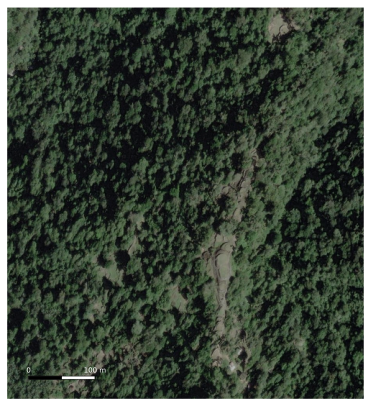

In [65]:
# Recorte e imagen final -> SVG / PNG

# z18 es el maximo nativo aqui: z19-z21 devuelven la misma tesela de relleno.
ZOOM = 18
ANCHO_IN = 4.961

# Recorte del mapa (grados). Ajusta estos limites para reencuadrar.
LAT_MIN, LAT_MAX = 11.0365, 11.0418
LON_MIN, LON_MAX = -73.92812, -73.9232

MARGEN_DESCARGA = 0.001  # grados extra para que el recorte nunca quede sin teselas
REALCE = dict(contraste=(2.0, 98.0), ganancia=0.05, saturacion=0.65, nitidez=0.5, radio=1.0)
BARRA_M = 100

img, img_extent = basemap(LAT_MIN - MARGEN_DESCARGA, LAT_MAX + MARGEN_DESCARGA,
                          LON_MIN - MARGEN_DESCARGA, LON_MAX + MARGEN_DESCARGA, ZOOM)
img = realzar(img, **REALCE)

x0, y0 = lonlat2merc(LON_MIN, LAT_MIN)
x1, y1 = lonlat2merc(LON_MAX, LAT_MAX)
alto_in = ANCHO_IN * (y1 - y0) / (x1 - x0)

# dpi >= resolucion nativa del recorte, para no perder pixeles al rasterizar
px_recorte = img.shape[1] * (x1 - x0) / (img_extent[1] - img_extent[0])
DPI = max(200, int(np.ceil(px_recorte / ANCHO_IN)))

fig, ax = plt.subplots(figsize=(ANCHO_IN, alto_in))
ax.imshow(img, extent=img_extent, origin="upper", interpolation="lanczos")
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect("equal")
ax.set_axis_off()
barra_escala(ax, BARRA_M, (LAT_MIN + LAT_MAX) / 2)

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig("teyuna_satelital.svg", format="svg", bbox_inches="tight", pad_inches=0, dpi=DPI)
fig.savefig("teyuna_satelital.png", dpi=DPI, bbox_inches="tight", pad_inches=0)
print(f"Saved -> teyuna_satelital.svg / .png  ({ANCHO_IN:.1f} x {alto_in:.1f} in, "
      f"{px_recorte:.0f} px nativos, dpi={DPI})")
